<a href="https://colab.research.google.com/github/opherdonchin/BayesShortCourse/blob/main/sleep/solved/01_linear_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sleep deprivation 1 — Linear baseline

Start with one population-average linear relationship. Because `Days = 0` is the pre-deprivation baseline, the intercept has a direct scientific interpretation and we put its prior on that scale.

## Setup

This course pins PyMC and the modular ArviZ packages for reproducibility because their APIs can change across major versions.

In [1]:
%pip install -q \
    "pandas==2.2.3" \
    "pymc==6.3.2" \
    "arviz-base==1.3.0" \
    "arviz-stats==1.3.2" \
    "arviz-plots[matplotlib]==1.3.1"

Note: you may need to restart the kernel to use updated packages.


D:\Repositories\BayesShortCourse\tmp\colabenv\Scripts\python.exe: No module named pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from pymc.stats.log_density import compute_log_density
import pymc as pm
import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs

RANDOM_SEED = 20260924
azp.style.use("arviz-variat")

print("PyMC:", pm.__version__)
print("arviz-base:", azb.__version__)
print("arviz-plots:", azp.__version__)
print("arviz-stats:", azs.__version__)

from pathlib import Path

NOTEBOOK = "01_linear_baseline"
FIG_DIR = Path("../../Slides/figures") if Path("../../Slides").is_dir() else Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_slide_figure(fig, section, number=None):
    """Save a Matplotlib figure or ArviZ PlotCollection for the slides."""
    suffix = f"_{number}" if number else ""
    fig.savefig(
        FIG_DIR / f"{NOTEBOOK}_{section}{suffix}.svg", bbox_inches="tight", transparent=True
    )

g++ not available, if using conda: `conda install gxx`


PyMC: 6.3.2
arviz-base: 1.3.0
arviz-plots: 1.3.1
arviz-stats: 1.3.2


### Data

The original study contains two adaptation/training days followed by a baseline measurement and then seven nights of severe sleep restriction. You can read about the original study here: [Belenky J Sleep Res. 2003](https://doi.org/10.1046/j.1365-2869.2003.00337.x)

Following the chapter, we drop original days 0–1 and subtract 2 from the remaining day number. Therefore **`Days = 0` is the baseline measurement before sleep deprivation begins**.

That zero point is scientifically meaningful, so every model in this sequence keeps `Days` on its natural scale (no centering). The intercept prior is therefore a prior on baseline reaction time rather than reaction time at the average deprivation day.

In [3]:
DATA_URL = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/lme4/sleepstudy.csv"

raw = pd.read_csv(DATA_URL).drop(columns="rownames")
sleep = raw.loc[raw["Days"] >= 2].copy()
sleep["Days"] = sleep["Days"] - 2
sleep["Subject"] = sleep["Subject"].astype(str)
sleep = sleep.reset_index(drop=True)

print(f"{sleep['Subject'].nunique()} participants, {len(sleep)} observations")
print(f"Days: {sleep['Days'].min()} to {sleep['Days'].max()}")
sleep.head()

18 participants, 144 observations
Days: 0 to 7


,Reaction,Days,Subject
0,250.8006,0,308
1,321.4398,1,308
2,356.8519,2,308
3,414.6901,3,308
4,382.2038,4,308


Each grey line is one participant, on the original study-day numbering. Days 0–1 were adaptation and training, day 2 is the baseline, and restriction begins after day 2.

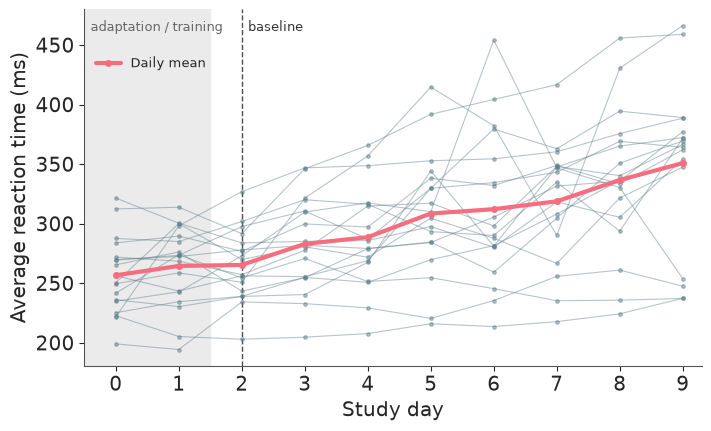

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.axvspan(-0.5, 1.5, color="0.92", zorder=0)
ax.axvline(2, color="0.3", linestyle="--", linewidth=1)
ax.text(-0.4, 0.97, "adaptation / training", transform=ax.get_xaxis_transform(),
        va="top", color="0.4", fontsize=9)
ax.text(2.1, 0.97, "baseline", transform=ax.get_xaxis_transform(),
        va="top", color="0.2", fontsize=9)
for _, person in raw.groupby("Subject"):
    ax.plot(person["Days"], person["Reaction"], color="#5f7f8a",
            marker="o", ms=2.5, lw=0.8, alpha=0.45)
daily_mean = raw.groupby("Days")["Reaction"].mean()
ax.plot(daily_mean.index, daily_mean.to_numpy(), color="C1", marker="o", ms=4, lw=3,
        label="Daily mean")
ax.set(xlabel="Study day", ylabel="Average reaction time (ms)",
       xticks=range(10), xlim=(-0.5, 9.3))
ax.legend(loc="upper left", bbox_to_anchor=(0, 0.9), frameon=False, fontsize=9)
save_slide_figure(fig, "data")
plt.show()

### Plotting helpers

These helper functions draw the regression and its uncertainties. There are two: one for showing population regressions and one for showing individual regressions.


#### Format colors

In [5]:
# orange mean line, blue 50% and 90% HDI bands, black observed points.
LM_VISUALS = {
    "pe_line": {"color": "C1"},
    "ci_band": {"color": "C0"},
    "observed_scatter": {"color": "black", "alpha": 1, "zorder": 3, "s": 10},
}
PARTICIPANT_DAY = xr.Coordinates.from_pandas_multiindex(
    pd.MultiIndex.from_frame(sleep[["Subject", "Days"]], names=["participant", "day"]),
    "obs_id",
)


#### plot_population

Plot any model variable against days using `plot_lm`.

In [6]:
def plot_population(dt, var, group="posterior"):
    """Single-panel trend of `var` against days, with all raw observations."""
    pc = azp.plot_lm(
        dt,
        x="days",
        y=var,
        y_obs="y",
        group=group,
        plot_dim="obs_id",
        ci_prob=(0.50, 0.90),
        ci_kind="hdi",
        point_estimate="mean",
        smooth=False,
        figure_kwargs={"figsize": (7, 4)},
        visuals={
            **LM_VISUALS,
            "xlabel": False,
            "ylabel": False,
        },
    )

    pc.facet_map("labelled_x", text="Days of sleep deprivation")
    pc.facet_map("labelled_y", text="Reaction time (ms)")
    pc.add_legend("prob", title="HDI")

    return pc

#### plot_participants

The same display, faceted by participant.

In [7]:
def plot_participants(dt, group, var):
    """One panel per participant: bands for `var` against days, with that participant's data."""
    def reshape(ds):
        return ds.assign_coords(PARTICIPANT_DAY).unstack("obs_id")

    panels = xr.DataTree.from_dict({
        group: reshape(dt[group].to_dataset()),
        "observed_data": reshape(dt["observed_data"].to_dataset()),
        "constant_data": reshape(dt["constant_data"].to_dataset()),
    })

    pc = azp.plot_lm(
        panels,
        x="days",
        y=var,
        y_obs="y",
        group=group,
        plot_dim="day",
        ci_prob=(0.50, 0.90),
        ci_kind="hdi",
        point_estimate="mean",
        smooth=False,
        cols=["participant"],
        col_wrap=6,
        figure_kwargs={"figsize": (11, 5.5), "sharex": True, "sharey": True},
        visuals={**LM_VISUALS, "xlabel": False, "ylabel": False},
    )

    pc.add_legend("prob", title="HDI")

    fig = pc.get_viz("figure")
    fig.supxlabel("Days of sleep deprivation")
    fig.supylabel("Reaction time (ms)")

    return pc

## 1. Model — What model should we start with?

### 1.1 What is the simplest useful model we can start with?

What is the simplest useful model we can start with for reaction time as sleep deprivation progresses?

We will start with a population-level linear regression: reaction time changes linearly with days of sleep deprivation, with normally distributed variation around that line.

$$
y_i \sim \operatorname{Normal}(\mu_i, sd_y)
$$

$$
\mu_i = b_0 + b_1\,\mathrm{days}_i
$$

### 1.2 What role does each quantity play in the model?

Classify `days`, `y`, `b0`, `b1`, `sd_y`, and `mu` as **input data**, an **observed outcome**, an **unknown parameter**, or a **deterministic calculation**.

- `days`: input data
- `y`: observed outcome
- `b0`: unknown parameter
- `b1`: unknown parameter
- `sd_y`: unknown parameter
- `mu`: deterministic calculation

### 1.3 What prior should we use for baseline reaction time?

We are fairly sure that almost all alert reaction times are between 50 and 450 ms. What Normal distribution would put approximately 95% of its probability between those two extremes?

The midpoint is 250 ms, and 50–450 ms is approximately $250 \pm 2(100)$ ms, so we use

$$
b_0 \sim \operatorname{Normal}(250, 100).
$$

### 1.4 Store the prior for `b0`.

Assign the mean and standard deviation from the previous answer to `mu_b0` and `sd_b0`.

In [8]:
mu_b0 = 250
sd_b0 = 100

### 1.5 What prior should we use for the daily effect of sleep deprivation?

We are intentionally putting aside our prior knowledge that sleep deprivation is unlikely to improve reaction time. Suppose instead that we use a symmetric Normal prior centered at zero and regard almost all population-average changes between −40 and +40 ms per day as plausible. What Normal distribution expresses that assumption?

A Normal distribution centered at 0 with standard deviation 20 ms/day puts approximately 95% of its probability between −40 and +40 ms/day:

$$
b_1 \sim \operatorname{Normal}(0, 20).
$$

### 1.6 Store the prior for `b1`.

Assign the mean and standard deviation from the previous answer to `mu_b1` and `sd_b1`.

In [9]:
mu_b1 = 0
sd_b1 = 20

### 1.7 What prior should we use for the residual variation?

The width of the likelihood, `sd_y`, must be positive. Suppose we use an Exponential prior and expect its mean to be 50 ms. What value should its scale parameter have?

For an Exponential distribution parameterized by its scale, the mean equals the scale. Therefore

$$
sd_y \sim \operatorname{Exponential}(\mathrm{scale}=50\ \mathrm{ms}).
$$

### 1.8 Store the prior mean for `sd_y`.

Assign the value from the previous answer to `mu_sd_y`.

In [10]:
mu_sd_y = 50

### 1.9 Which PyMC distribution functions do we need?

What are the names of the PyMC distribution functions that we should use to represent Normal distributions and Exponential distributions in the model?

`pm.Normal` and `pm.Exponential`.

### 1.10 Implement the model in PyMC.

Use `pm.Model`, `pm.Data`, `pm.Normal`, `pm.Exponential`, and `pm.Deterministic` to implement the model above. Use the prior constants you defined and name the model variables `days`, `b0`, `b1`, `sd_y`, `mu`, and `y`.

In [11]:
coords = {"obs_id": np.arange(len(sleep))}

with pm.Model(coords=coords) as model:
    days = pm.Data("days", sleep["Days"].to_numpy(), dims="obs_id")

    b0 = pm.Normal("b0", mu=mu_b0, sigma=sd_b0)
    b1 = pm.Normal("b1", mu=mu_b1, sigma=sd_b1)
    sd_y = pm.Exponential("sd_y", scale=mu_sd_y)

    mu = pm.Deterministic("mu", b0 + b1 * days, dims="obs_id")

    y = pm.Normal(
        "y",
        mu=mu,
        sigma=sd_y,
        observed=sleep["Reaction"].to_numpy(),
        dims="obs_id",
    )

## 2. Prior predictive check — What does the model imply before seeing the outcomes?

### 2.1 What distribution describes the predictions of the model and priors?

To see what the implications of our model and priors are, we sample parameters from the prior and then sample data from the likelihood given those parameters. What is the name of the distribution we get when we do this?

The **prior predictive distribution**.

### 2.2 What PyMC function samples from that distribution?

What PyMC function generates samples from the prior predictive distribution?

`pm.sample_prior_predictive`.

### 2.3 Generate prior predictive reaction times.

Draw 500 samples from the prior predictive distribution for `y`.

In [12]:
with model:
    prior = pm.sample_prior_predictive(
        draws=500,
        var_names=["y"],
        random_seed=RANDOM_SEED,
    )

Sampling: [b0, b1, sd_y, y]


### 2.4 What should we look for in the prior predictive simulations?

Before examining the plot, what criteria should we use to decide whether the predictions implied by the priors are reasonable?

We will use three broad criteria:

1. Predicted reaction times should not routinely be physically impossible.
2. Reaction times near the beginning of the experiment should mostly occupy a broadly plausible range.
3. The model should allow substantial changes over the seven days without routinely generating absurd trajectories.

The goal is broad plausibility, not tuning the priors to reproduce the observed data.

### 2.5 Plot the prior predictive reaction times.

Use the supplied `plot_participants` function to plot the prior predictive reaction times `y` for each participant.

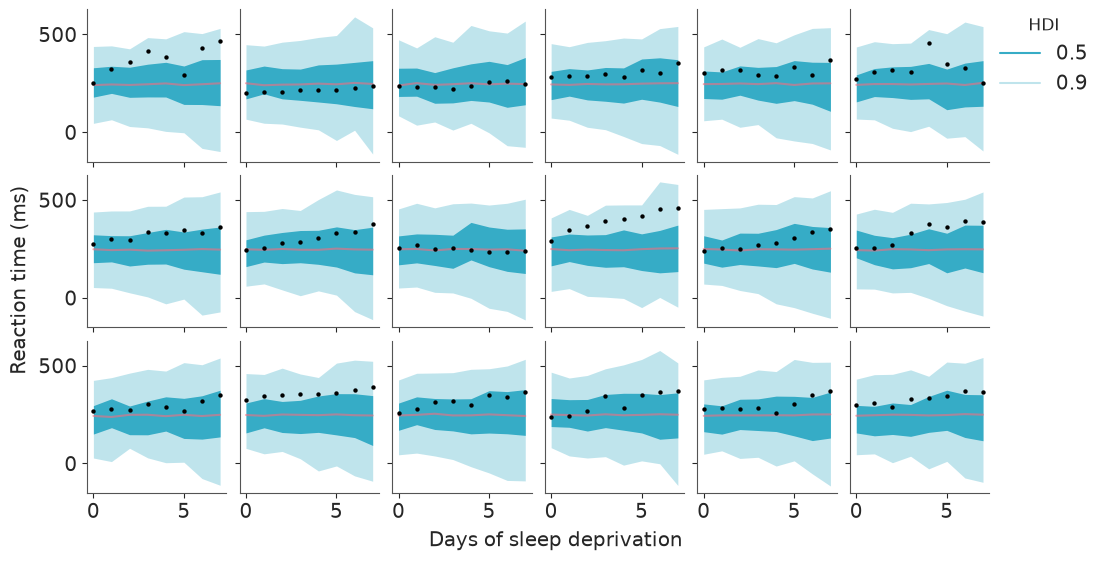

In [13]:
plot_participants(prior, "prior_predictive", "y")
plt.show()

### 2.6 Are the prior predictions reasonable enough to proceed?

Do the prior predictive simulations satisfy the criteria in Question 2.4 well enough to continue with the model?

Broadly, yes. The prior predictive distribution is deliberately wide and includes some extreme values, but it places substantial probability on realistic baseline reaction times and allows both modest and large changes across the experiment without making physically impossible values routine.

## 3. Fit — What parameter values are compatible with the data?

### 3.1 What PyMC function samples from the posterior?

What PyMC function should we use to draw samples from the posterior distribution?

`pm.sample`.

### 3.2 Fit the model.

Use `pm.sample` to draw 1000 samples in each of 4 chains from the posterior distribution, with 1500 tuning samples.

In [14]:
with model:
    idata = pm.sample(
        draws=1000,
        tune=1500,
        chains=4,
        random_seed=RANDOM_SEED,
    )

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [b0, b1, sd_y]


Output()

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 8 seconds.


## 4. Diagnose — Did posterior sampling work adequately?

### 4.1 What will tell us that sampling has succeeded?

When we look at our diagnostic table and plots, what will tell us that the sampling has succeeded?

We want to see no divergences, $\hat R$ values no larger than about 1.01, bulk and tail effective sample sizes comfortably in the hundreds or more, and traces in which the chains mix together without obvious chain-specific behavior.

### 4.2 What ArviZ Stats function gives us the main numerical diagnostics?

What ArviZ Stats function produces a table containing $\hat R$, bulk ESS, and tail ESS?

`azs.summary`.

### 4.3 Calculate the numerical diagnostics.

Use `idata["sample_stats"]["diverging"].sum().item()` to count divergences, and use `azs.summary` to summarize `b0`, `b1`, and `sd_y` with a 90% HDI.

In [15]:
print("Divergences:", int(idata["sample_stats"]["diverging"].sum().item()))

azs.summary(
    idata,
    var_names=["b0", "b1", "sd_y"],
    ci_prob=0.90,
    ci_kind="hdi",
    round_to=2,
)

Divergences: 0


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
b0,268.30,8.11,254.82,281.49,1619.96,1797.40,1.0,0.20,0.15
b1,11.33,1.92,8.20,14.46,1793.90,1839.08,1.0,0.05,0.04
sd_y,51.05,3.05,46.10,55.97,2333.95,2266.19,1.0,0.06,0.05


### 4.4 What ArviZ Plots function shows posterior distributions and traces together?

What ArviZ Plots function combines the marginal posterior distribution of each parameter with its sampling traces?

`azp.plot_trace_dist`.

### 4.5 Plot the posterior distributions and traces.

Use `azp.plot_trace_dist` for `b0`, `b1`, and `sd_y`.

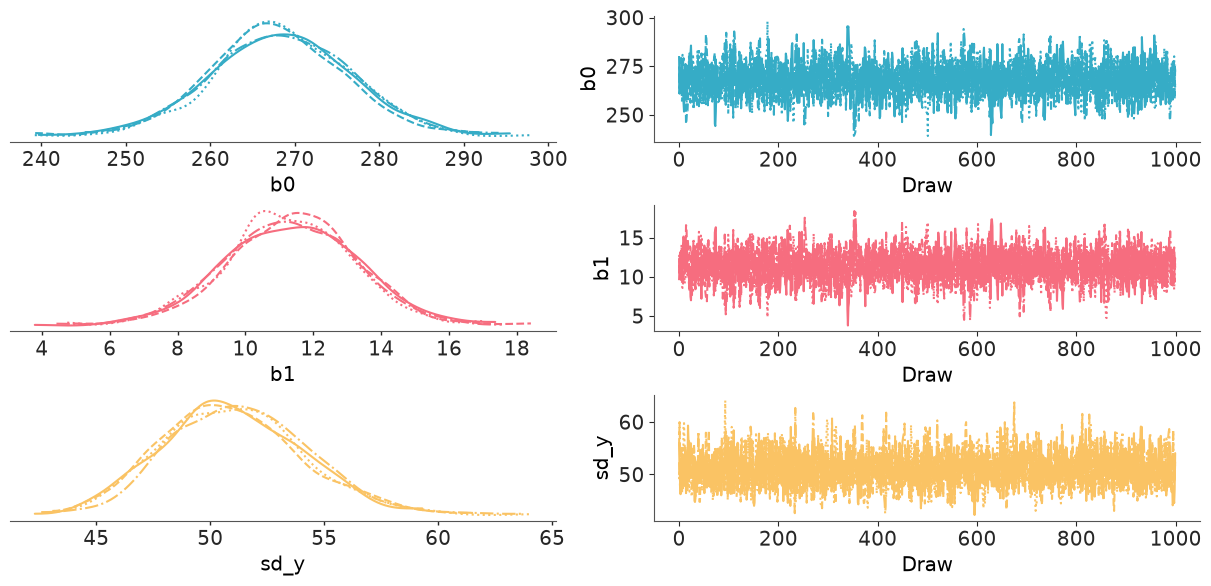

In [16]:
azp.plot_trace_dist(idata, var_names=["b0", "b1", "sd_y"]);

### 4.6 Did sampling succeed?

Do the numerical and graphical diagnostics meet the criteria outlined in Question 4.1?

Yes. The fit has no divergences, the $\hat R$ values are essentially 1, the effective sample sizes are large, and the traces show the chains mixing over the same stationary distributions.

## 5. Interpret — What have we learned from the fitted model?

### 5.1 What function plots the posterior distribution of a single variable?

What ArviZ Plots function can show the marginal posterior distribution, point estimate, and credible interval for one parameter?

`azp.plot_dist`.

### 5.2 Plot the posterior distribution of `b0`.

Use `azp.plot_dist` to plot `b0` with a 90% HDI.

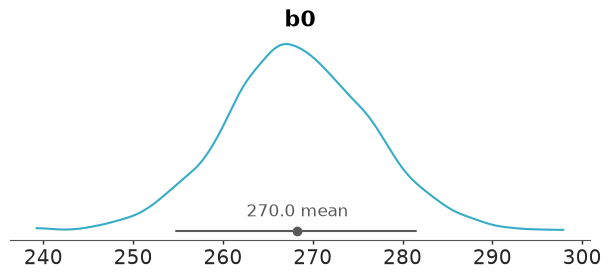

In [17]:
azp.plot_dist(
    idata,
    var_names=["b0"],
    ci_prob=0.90,
    ci_kind="hdi",
);

### 5.3 What baseline reaction times are credible?

Using the 90% HDI from your summary table, what range of values for baseline reaction time is credible given the model and the data?

Approximately **257–283 ms** for the population baseline reaction time.

### 5.4 Plot the posterior distribution of `b1`.

Use `azp.plot_dist` to plot `b1` with a 90% HDI.

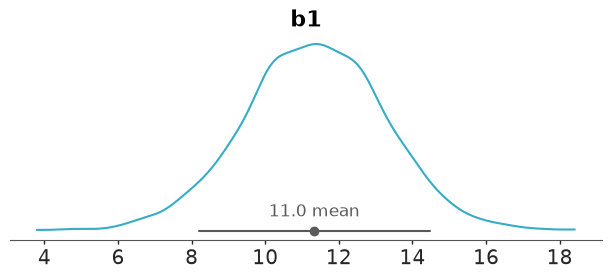

In [18]:
azp.plot_dist(
    idata,
    var_names=["b1"],
    ci_prob=0.90,
    ci_kind="hdi",
);

### 5.5 What daily effects are credible?

Using the 90% HDI from your summary table, what range of population-average changes in reaction time per day is credible given the model and the data?

Approximately **8–14 ms/day** of slowing.

### 5.6 Plot the posterior distribution of `sd_y`.

Use `azp.plot_dist` to plot `sd_y` with a 90% HDI.

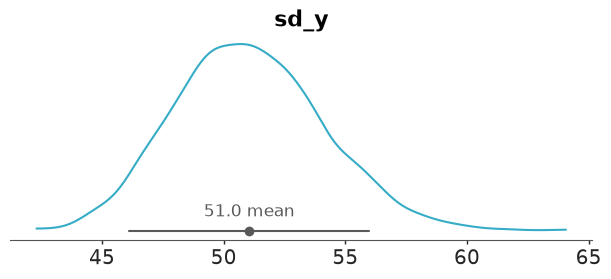

In [19]:
azp.plot_dist(
    idata,
    var_names=["sd_y"],
    ci_prob=0.90,
    ci_kind="hdi",
);

### 5.7 What residual variation is credible?

Using the 90% HDI from your summary table, what range of values for the residual standard deviation `sd_y` is credible given the model and the data?

Approximately **46–56 ms**.

### 5.8 Which model quantity represents the expected reaction time on each day?

Which variable in the model represents the population-average expected reaction time on each day, without the residual observation noise?

`mu`.

### 5.9 Plot the population-average trajectory.

Use the supplied `plot_population` function to plot the posterior distribution of `mu` across days.

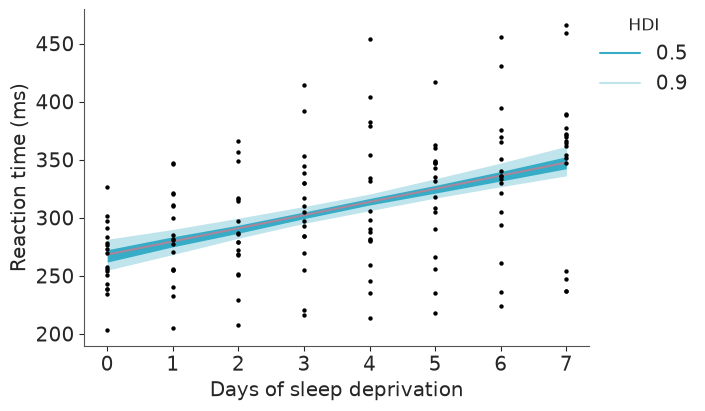

In [20]:
plot_population(idata, "mu")
plt.show()

### 5.10 What uncertainty do the bands represent?

Is the uncertainty shown by the bands in this plot uncertainty about the mean or uncertainty about future data?

It is uncertainty about the **population-average mean reaction time** `mu`. It does not include the residual variability of future reaction-time observations around that mean.

## 6. Prior sensitivity — Would modest changes in the priors alter our conclusions?

### 6.1 How can we check whether the posterior depends strongly on the priors?

We did not cover this method in the lecture, so here we will introduce it before using it.

**Power-scaling sensitivity** slightly weakens and strengthens either the prior or the likelihood and asks how much the posterior changes. Conceptually, it replaces a density $p$ by $p^\alpha$ for values of $\alpha$ just below and just above 1. ArviZ uses importance reweighting, so we can assess this local sensitivity without refitting the model many times.

A large change in the posterior after only a small change in prior weight indicates that the posterior is sensitive to the prior.

### 6.2 What would strong prior sensitivity mean?

If slightly strengthening or weakening a prior causes a substantial change in the posterior for a parameter, what would that tell us about our conclusion for that parameter?

It would tell us that the posterior conclusion for that parameter depends meaningfully on the prior specification, so modest alternative priors could change the result.

### 6.3 What information does ArviZ need for power-scaling?

To reweight the posterior, ArviZ needs the log prior density and the pointwise log likelihood for each posterior draw. The next cell adds both quantities to `idata`.

In [21]:
with model:
    pm.compute_log_likelihood(idata)
    compute_log_density(idata, model=model, kind="prior", extend_inferencedata=True)

Output()

Output()

### 6.4 What function summarizes power-scaling sensitivity?

What ArviZ Stats function computes a table of prior and likelihood sensitivity for posterior variables?

`azs.psense_summary`.

### 6.5 Calculate power-scaling sensitivity.

Use `azs.psense_summary` for `b0`, `b1`, and `sd_y`.

In [22]:
azs.psense_summary(
    idata,
    var_names=["b0", "b1", "sd_y"],
)

,prior,likelihood,diagnosis
b0,0.006,0.103,✓
b1,0.007,0.107,✓
sd_y,0.011,0.122,✓


### 6.6 How should we read the sensitivity table?

ArviZ uses 0.05 as a screening threshold. Prior sensitivity above 0.05 suggests an informative prior; if prior and likelihood sensitivity are both above 0.05, it flags a potential prior-data conflict. If prior sensitivity is above 0.05 while likelihood sensitivity is below 0.05, it flags a potential strong-prior/weak-likelihood situation.

### 6.7 Does the sensitivity check flag a problem?

Does the `diagnosis` column flag any potential prior-data conflict or strong-prior/weak-likelihood behavior for `b0`, `b1`, or `sd_y`?

No. The summary does not flag any of the three parameters; their prior sensitivities are all well below 0.05.

## 7. Posterior predictive check — Can the fitted model reproduce the data?

### 7.1 What distribution describes new data generated from the fitted model?

After fitting the model, we can draw parameter values from the posterior and then generate new observations from the likelihood. What is the name of the resulting distribution?

The **posterior predictive distribution**.

### 7.2 What PyMC function samples from the posterior predictive distribution?

What PyMC function generates posterior predictive samples?

`pm.sample_posterior_predictive`.

### 7.3 Generate posterior predictive reaction times.

Use `pm.sample_posterior_predictive` to generate new values of `y` from the fitted model and add them to `idata`.

In [23]:
with model:
    pm.sample_posterior_predictive(
        idata,
        var_names=["y"],
        extend_inferencedata=True,
        random_seed=RANDOM_SEED,
    )

Sampling: [y]


Output()

### 7.4 What should we look for in the posterior predictive check?

Before looking at the participant plots, what features should we compare between the observed and replicated data?

Look for whether the model reproduces:

1. participants' overall reaction-time levels;
2. changes in reaction time across days; and
3. observation-to-observation variation around those trends.

Pay particular attention to discrepancies that persist across many observations from the same participant rather than isolated misses.

### 7.5 Plot the posterior predictive reaction times.

Use the supplied `plot_participants` function to plot posterior predictive reaction times `y` together with the observed reaction times for each participant.

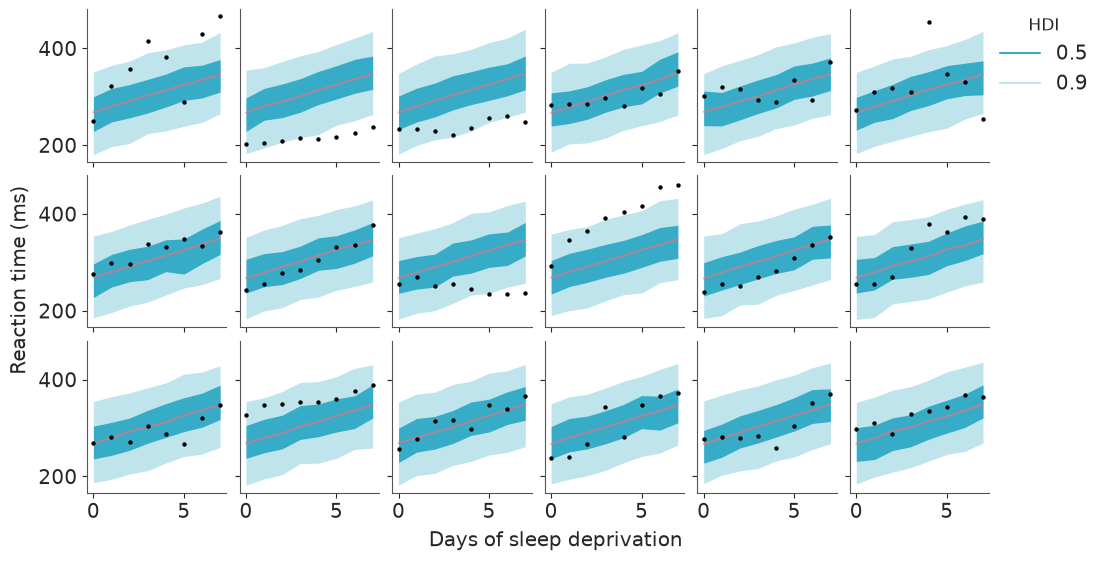

In [24]:
plot_participants(idata, "posterior_predictive", "y")
plt.show()

### 7.6 What does the population-average model fail to reproduce most clearly?

Which of the features listed in Question 7.4 does the model fail to reproduce most clearly?

The clearest failure is **participant-to-participant differences in overall reaction-time level**: whole participants tend to remain systematically above or below the population prediction. Some participants also show different trajectory shapes. The single population line treats this persistent between-person structure as residual noise.